In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [20]:
df_train = pd.read_csv('../Predicting F1 Pit Stops/data/train.csv')
display(df_train.head())
df_train.info(memory_usage='deep')

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [21]:
miss_data=df_train.isnull().sum()
print("Пусті значення:",miss_data.sum())

Пусті значення: 0


In [22]:
target_count = (df_train['PitNextLap'].value_counts(normalize=True) * 100).round()
target_count

PitNextLap
0.0    80.0
1.0    20.0
Name: proportion, dtype: float64

In [23]:
df_train['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [24]:
df_train.groupby('Race')['PitStop'].agg(['sum','count']).sort_values(by='count', ascending=False)

,sum,count
Race,,
Dutch Grand Prix,4346,24462
Mexico City Grand Prix,2699,23672
Pre-Season Testing,1746,22492
Hungarian Grand Prix,2747,22481
Monaco Grand Prix,1431,21539
Canadian Grand Prix,3492,21416
Austrian Grand Prix,5081,21223
Spanish Grand Prix,3110,20483
Italian Grand Prix,2211,19854


In [25]:
df_train = df_train.drop('id', axis=1)
df_train.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


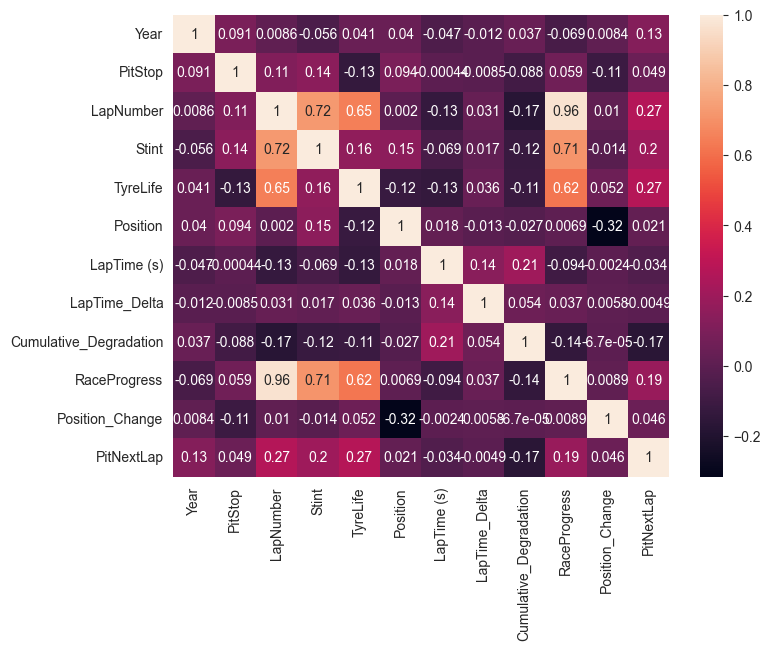

In [26]:
numeric_col = df_train.select_dtypes(['int','float'])
plt.figure(figsize = (8,6))
sns.heatmap(numeric_col.corr(), annot=True)
plt.show()

In [28]:
# Можна прибрати RaceProgress, бо ця фіча має велику кореляцію з LapNumber
df_train = df_train.drop('RaceProgress', axis=1)